--- Chargement : ../datasets/schaefcomb_Wang2023Simple_dfschizo.tsv ---


/tmp/ipykernel_376687/1750735010.py:33: DtypeWarning: Columns (93968) have mixed types. Specify dtype option on import or set low_memory=False.
  df_all = pd.read_csv(DATA_PATH, sep="\t")


Dataset fusionné : 389 sujets, 88932 features.

DÉBUT LEARNING CURVE | RIDGE | AVEC PROGRESS BAR
Lancement des calculs...


Progression Learning Curve: 100%|██████████| 10/10 [28:05<00:00, 168.58s/it]



--- Calcul terminé ---

--- Résultats ---
N_train=31   | AUC Validation: 0.703 (+/- 0.072)
N_train=62   | AUC Validation: 0.775 (+/- 0.045)
N_train=93   | AUC Validation: 0.809 (+/- 0.039)
N_train=124  | AUC Validation: 0.807 (+/- 0.033)
N_train=155  | AUC Validation: 0.828 (+/- 0.042)
N_train=186  | AUC Validation: 0.834 (+/- 0.053)
N_train=217  | AUC Validation: 0.845 (+/- 0.052)
N_train=248  | AUC Validation: 0.848 (+/- 0.062)
N_train=279  | AUC Validation: 0.858 (+/- 0.055)
N_train=311  | AUC Validation: 0.861 (+/- 0.054)

Graphique sauvegardé : ../results_learning_curve/learning_curve_ridge_tqdm.png


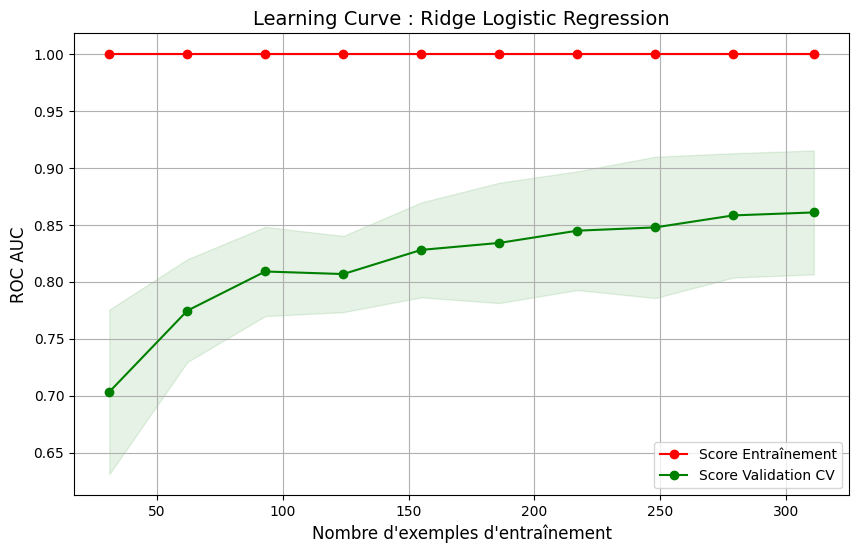

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
from tqdm import tqdm  # <--- IMPORT TQDM
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegressionCV
from sklearn.model_selection import learning_curve, StratifiedKFold
from sklearn.metrics import roc_auc_score

# ============================================================
# 0) CONFIGURATION & NETTOYAGE
# ============================================================
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

warnings.filterwarnings("ignore", message="Skipping features without any observed values")
warnings.filterwarnings("ignore", category=UserWarning, module="sklearn.linear_model")

DATA_PATH = "../datasets/schaefcomb_Wang2023Simple_dfschizo.tsv"
OUTPUT_DIR = "../results_learning_curve"

if not os.path.exists(OUTPUT_DIR):
    os.makedirs(OUTPUT_DIR)

# ============================================================
# 1) CHARGEMENT ET PRÉPARATION
# ============================================================
print(f"--- Chargement : {DATA_PATH} ---")
df_all = pd.read_csv(DATA_PATH, sep="\t")

mask_sites = df_all["site_id"].isin(["ds000030", "ds_cobre", "ds004302"])
mask_diag = df_all["diagnosis"].isin(["CONTROL", "SCHZ"])
df_clean = df_all.loc[mask_sites & mask_diag].copy()

y = (df_clean["diagnosis"] == "SCHZ").astype(int)

# Filtre initial : colonnes remplies à >50%
X_temp = df_clean[[c for c in df_clean.columns if c.startswith("corr_")]]
threshold = 0.5 * len(X_temp)
corr_cols = X_temp.columns[X_temp.notna().sum() > threshold].tolist()
X = df_clean[corr_cols]

print(f"Dataset fusionné : {X.shape[0]} sujets, {X.shape[1]} features.")

# ============================================================
# 2) MODÈLE
# ============================================================
def get_model():
    return Pipeline([
        ("imputer", SimpleImputer(strategy="mean")), 
        ("scaler", StandardScaler()), 
        ("clf", LogisticRegressionCV(
            cv=5, 
            penalty='l2',        
            solver='liblinear', 
            scoring='roc_auc', 
            class_weight='balanced', 
            max_iter=5000, 
            n_jobs=1,  # Important : 1 cœur par modèle pour éviter saturation RAM
            random_state=RANDOM_SEED
        ))
    ])

# ============================================================
# 3) LEARNING CURVE AVEC TQDM
# ============================================================
print("\n" + "="*60)
print(f"DÉBUT LEARNING CURVE | RIDGE | AVEC PROGRESS BAR")
print("="*60)

# On définit nos étapes (10% à 100% par pas de 10%)
ratios = np.linspace(0.1, 1.0, 10)
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)

# Listes pour stocker les résultats étape par étape
lc_train_sizes = []
lc_train_scores = []
lc_test_scores = []

print("Lancement des calculs...")

# --- BOUCLE MANUELLE TQDM ---
for ratio in tqdm(ratios, desc="Progression Learning Curve"):
    
    # On appelle learning_curve pour UN SEUL ratio à la fois
    # Cela permet de mettre à jour la barre de progression à chaque ratio
    sizes_abs, train_sc, test_sc = learning_curve(
        estimator=get_model(),
        X=X,
        y=y,
        train_sizes=[ratio], # On passe une liste contenant juste le ratio actuel
        cv=cv_strategy,
        scoring='roc_auc',
        n_jobs=4,  # Parallélisme au niveau des folds (4 cœurs)
        verbose=0  # On désactive le verbose sklearn car on a tqdm
    )
    
    # On stocke les résultats
    lc_train_sizes.append(sizes_abs[0])
    lc_train_scores.append(train_sc[0]) # train_sc est de forme (1, n_folds)
    lc_test_scores.append(test_sc[0])

# Reconversion en numpy array pour faciliter les calculs ensuite
# Forme attendue : (n_steps, n_folds)
train_scores_matrix = np.array(lc_train_scores)
test_scores_matrix = np.array(lc_test_scores)
train_sizes_abs = np.array(lc_train_sizes)

print("\n--- Calcul terminé ---")

# ============================================================
# 4) ANALYSE ET VISUALISATION
# ============================================================
train_mean = np.mean(train_scores_matrix, axis=1)
train_std = np.std(train_scores_matrix, axis=1)
test_mean = np.mean(test_scores_matrix, axis=1)
test_std = np.std(test_scores_matrix, axis=1)

print("\n--- Résultats ---")
for size, mean, std in zip(train_sizes_abs, test_mean, test_std):
    print(f"N_train={size:<4} | AUC Validation: {mean:.3f} (+/- {std:.3f})")

plt.figure(figsize=(10, 6))
plt.fill_between(train_sizes_abs, train_mean - train_std, train_mean + train_std, alpha=0.1, color="r")
plt.fill_between(train_sizes_abs, test_mean - test_std, test_mean + test_std, alpha=0.1, color="g")
plt.plot(train_sizes_abs, train_mean, 'o-', color="r", label="Score Entraînement")
plt.plot(train_sizes_abs, test_mean, 'o-', color="g", label="Score Validation CV")

plt.title("Learning Curve : Ridge Logistic Regression", fontsize=14)
plt.xlabel("Nombre d'exemples d'entraînement", fontsize=12)
plt.ylabel("ROC AUC", fontsize=12)
plt.legend(loc="best")
plt.grid(True)

plot_path = os.path.join(OUTPUT_DIR, "learning_curve_ridge_tqdm.png")
plt.savefig(plot_path, dpi=300)
print(f"\nGraphique sauvegardé : {plot_path}")
plt.show()

# Sauvegarde des données
df_lc = pd.DataFrame({
    "n_train_samples": train_sizes_abs,
    "train_auc_mean": train_mean,
    "train_auc_std": train_std,
    "test_auc_mean": test_mean,
    "test_auc_std": test_std
})
tsv_path = os.path.join(OUTPUT_DIR, "learning_curve_data.tsv")
df_lc.to_csv(tsv_path, sep="\t", index=False)